# Phase 3 — Model Comparison, Confusion Matrix, Calibration, SHAP

Loads the saved winning model (CatBoost — see `docs/baseline_results.md`) and visualizes what `docs/baseline_results.md` reports in text form. No retraining happens here.

In [1]:
import sys
sys.path.insert(0, "../../backend")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, precision_recall_curve

from app.models.classifier import build_classification_dataset, evaluate_classifier
from app.models.explain import compute_shap_values, shap_feature_importance
from app.models.feature_set import CATEGORICAL_FEATURES, NUMERIC_FEATURES

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

features = pd.read_parquet("../../data/processed/features.parquet")
targets = pd.read_parquet("../../data/processed/targets.parquet")
split = build_classification_dataset(features, targets)
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES

model = CatBoostClassifier()
model.load_model("../models/classifier_catboost.cbm")
print("Loaded CatBoost model. Test split:", len(split.test), "rows")


Loaded CatBoost model. Test split: 44767 rows


## 1. Test-set predictions + confusion matrix
Threshold fixed at the validation-chosen 0.30 (see baseline_results.md).

{'model': 'catboost_test', 'pr_auc': 0.8732, 'precision': 0.7341, 'recall': 0.9651, 'f1': 0.8339, 'brier_score': 0.1766, 'best_threshold': 0.3, 'n_samples': 44767, 'positive_rate': 0.7027, 'confusion_matrix': [[2310, 10999], [1098, 30360]]}


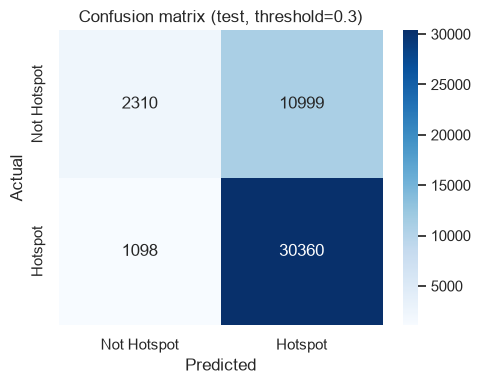

In [2]:
X_test = split.test[feature_cols]
y_test = split.test["target_hotspot_60m"].to_numpy()
proba_test = model.predict_proba(X_test)[:, 1]

THRESHOLD = 0.30
y_pred = (proba_test >= THRESHOLD).astype(int)
metrics = evaluate_classifier("catboost_test", y_test, proba_test, threshold=THRESHOLD)
print(metrics.to_dict())

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix (test, threshold={THRESHOLD})")
plt.tight_layout()
plt.show()


## 2. Precision-Recall curve
Shows the full precision/recall trade-off across thresholds, not just the single F1-optimal point used above.

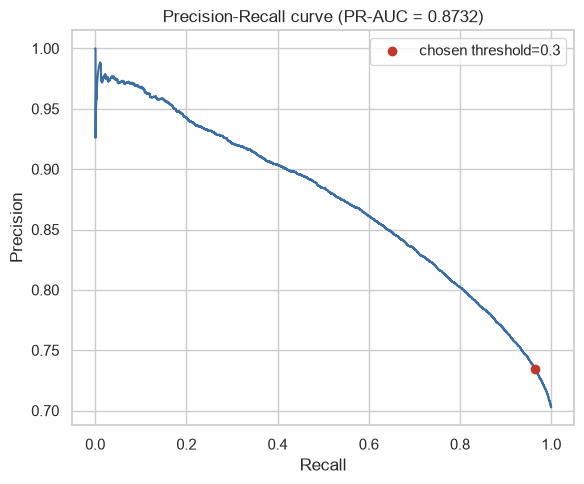

In [3]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, color="#3b6ea5")
ax.scatter([metrics.recall], [metrics.precision], color="#c0392b", zorder=5,
           label=f"chosen threshold={THRESHOLD}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (PR-AUC = {metrics.pr_auc:.4f})")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Calibration / reliability curve
If the model were perfectly calibrated, points would sit on the diagonal — a predicted probability of 0.7 should mean the event actually happens ~70% of the time.

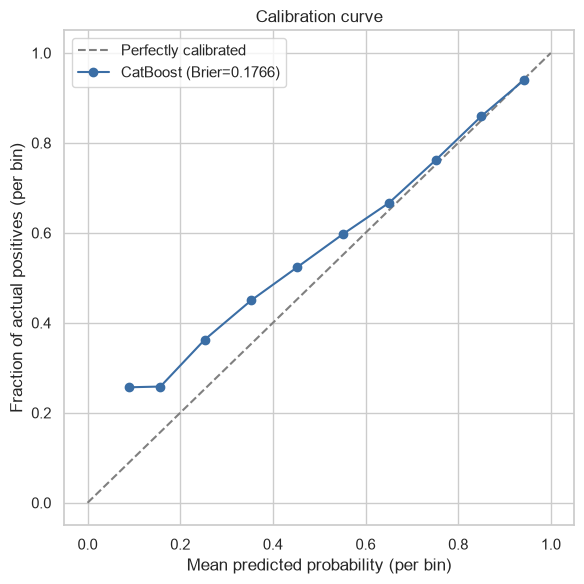

In [4]:
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", color="#3b6ea5", label=f"CatBoost (Brier={metrics.brier_score:.4f})")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Fraction of actual positives (per bin)")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.show()


## 4. SHAP summary plot
Global feature importance + direction of effect, on a sample of the validation set.

In [5]:
X_val = split.val[feature_cols]
shap_values, X_sample = compute_shap_values(model, X_val, max_samples=2000)
importance = shap_feature_importance(shap_values, feature_cols)
importance.head(15)


,feature,mean_abs_shap
0,h3_cell,0.433921
1,rolling_hotspot_intensity,0.237661
2,vehicle_type,0.138164
3,violations_last_15m,0.097867
4,hour_cos,0.085024
5,primary_offence_code,0.081220
6,violations_last_60m,0.058928
7,primary_violation_type,0.047035
8,center_code,0.042558
9,violation_density,0.041542


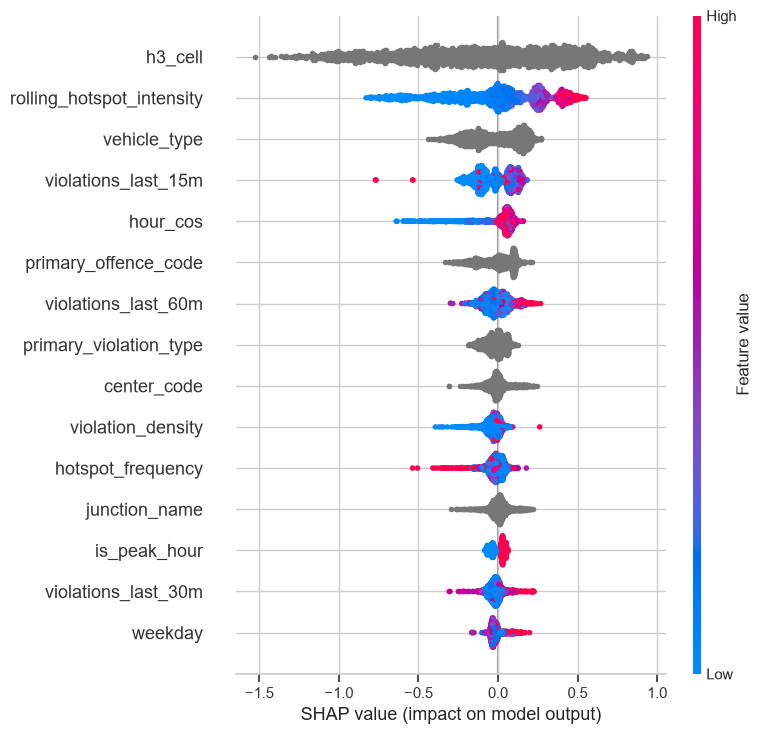

In [6]:
import shap
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.tight_layout()
plt.show()


## 5. Sample hotspot forecasts
A handful of real test-set rows with predicted probability vs. actual outcome — including both a confident-correct example and a false positive, since the confusion matrix shows the model over-predicts positives at this threshold.

In [7]:
sample_df = split.test[["created_datetime", "h3_cell"]].copy()
sample_df["predicted_probability"] = proba_test
sample_df["predicted_hotspot"] = y_pred
sample_df["actual_hotspot"] = y_test

# A few confident true positives
print("Confident TRUE POSITIVES (model correctly predicts hotspot):")
tp = sample_df[(sample_df.predicted_hotspot == 1) & (sample_df.actual_hotspot == 1)]
display(tp.nlargest(5, "predicted_probability"))

# A few false positives — the failure mode the confusion matrix flagged
print("\nFALSE POSITIVES (model predicts hotspot, but none occurred):")
fp = sample_df[(sample_df.predicted_hotspot == 1) & (sample_df.actual_hotspot == 0)]
display(fp.sample(min(5, len(fp)), random_state=42))

# A few false negatives
print("\nFALSE NEGATIVES (model misses a real hotspot):")
fn = sample_df[(sample_df.predicted_hotspot == 0) & (sample_df.actual_hotspot == 1)]
display(fn.sample(min(5, len(fn)), random_state=42))


Confident TRUE POSITIVES (model correctly predicts hotspot):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
272533,2024-03-26 18:09:46+00:00,8960145b59bffff,0.992094,1,1
272534,2024-03-26 18:10:46+00:00,8960145b59bffff,0.992094,1,1
285937,2024-04-02 03:33:46+00:00,8960145b553ffff,0.991233,1,1
285930,2024-04-02 03:32:46+00:00,8960145b553ffff,0.991173,1,1
272522,2024-03-26 18:04:46+00:00,8960145b59bffff,0.990131,1,1



FALSE POSITIVES (model predicts hotspot, but none occurred):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
254151,2024-03-14 23:29:46+00:00,8960145b58bffff,0.643458,1,0
275496,2024-03-28 02:52:46+00:00,89618924ccfffff,0.704416,1,0
281071,2024-03-31 00:08:46+00:00,89618925947ffff,0.541464,1,0
269206,2024-03-24 06:05:46+00:00,8961892e937ffff,0.835767,1,0
265994,2024-03-22 07:58:46+00:00,896189242afffff,0.719898,1,0



FALSE NEGATIVES (model misses a real hotspot):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
255364,2024-03-15 07:15:46+00:00,89618924b2bffff,0.286905,0,1
278104,2024-03-29 08:57:46+00:00,8961892e167ffff,0.274101,0,1
256033,2024-03-15 23:59:46+00:00,8961892c5abffff,0.180977,0,1
279845,2024-03-30 05:32:46+00:00,896014595b7ffff,0.202712,0,1
289722,2024-04-04 02:47:46+00:00,8960145a66bffff,0.275546,0,1


## Conclusion
- CatBoost is the Phase 3 winner — see `docs/baseline_results.md` for the full model comparison table.
- The model is recall-leaning at the chosen threshold: it rarely misses a real hotspot, at the cost of a high false-positive rate. Phase 6's alert engine needs to decide the right operating point given the real-world cost of a missed vs. a wasted patrol.
- Calibration is moderate (Brier ≈ 0.18, not near 0) — predicted probabilities are directionally useful but not exact percentages without further calibration work.
- SHAP confirms `h3_cell` and `rolling_hotspot_intensity` as the dominant signals, consistent with Experiment D in `docs/baseline_results.md` showing rolling features measurably outperform raw counts alone.